In [1]:
import pandas as pd
import numpy as np
import random
import os
import math
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    log_loss
)
from sklearn.pipeline import Pipeline

#**Data Collection**
**Dataset Used :** pd_speech features dataset

**Dataset Source :** UCI Machine Learning Repository

**Dataset Hosting URL :** https://archive.ics.uci.edu/dataset/470/parkinson+s+disease+classification

In [2]:
df = pd.read_csv('/content/pd_speech_features.csv')

In [3]:
df.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [4]:
print('Number of Features In Dataset :', df.shape[1])
print('Number of Instances In Dataset : ', df.shape[0])

Number of Features In Dataset : 755
Number of Instances In Dataset :  756


# **Data Preprocessing**
The following steps are performed on the dataset in this section:

    - Dropping Redudant Columns
    - Checking For Duplicated Rows
    - Checking For Missing Values


# Dropping The id Column

In [4]:
df.drop(['id'], axis=1, inplace=True)

In [5]:
print('Number of Features In Dataset :', df.shape[1])
print('Number of Instances In Dataset : ', df.shape[0])

Number of Features In Dataset : 754
Number of Instances In Dataset :  756


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 754 entries, gender to class
dtypes: float64(749), int64(5)
memory usage: 4.3 MB


In [8]:
df.describe()

,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,locAbsJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,7.560000e+02,...,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,0.515873,0.746284,0.700414,0.489058,323.972222,322.678571,0.006360,0.000383,0.002324,1.673391e-05,...,26.237251,22.840337,18.587888,13.872018,12.218953,12.375335,14.799230,14.751559,31.481110,0.746032
std,0.500079,0.169294,0.069718,0.137442,99.219059,99.402499,0.001826,0.000728,0.002628,2.290134e-05,...,42.220693,32.626464,25.537464,20.046029,17.783642,16.341665,15.722502,14.432979,34.230991,0.435568
min,0.000000,0.041551,0.543500,0.154300,2.000000,1.000000,0.002107,0.000011,0.000210,6.860000e-07,...,1.509800,1.531700,1.582900,1.747200,1.789500,1.628700,1.861700,1.955900,2.364000,0.000000
25%,0.000000,0.762833,0.647053,0.386537,251.000000,250.000000,0.005003,0.000049,0.000970,5.260000e-06,...,2.408675,3.452800,3.354825,3.077450,2.937025,3.114375,3.665925,3.741275,3.948750,0.000000
50%,1.000000,0.809655,0.700525,0.484355,317.000000,316.000000,0.006048,0.000077,0.001495,9.530000e-06,...,5.586300,7.062750,6.077400,4.770850,4.300450,4.741450,6.725700,7.334250,10.637250,1.000000
75%,1.000000,0.834315,0.754985,0.586515,384.250000,383.250000,0.007528,0.000171,0.002520,1.832500e-05,...,28.958075,29.830850,21.944050,13.188000,10.876150,12.201325,21.922050,22.495175,61.125325,1.000000
max,1.000000,0.907660,0.852640,0.871230,907.000000,905.000000,0.012966,0.003483,0.027750,2.564800e-04,...,239.788800,203.311300,121.542900,102.207000,85.571700,73.532200,62.007300,57.544300,156.423700,1.000000


In [7]:
df['class'] = df['class'].astype('uint8')

# Checking For Duplicate Rows In Dataset

In [8]:
print('Number of Duplicated Rows :',df.duplicated().sum())

Number of Duplicated Rows : 1


In [9]:
# Remove duplicated rows
df = df.drop_duplicates()

# Optional: reset index after removing duplicates
df = df.reset_index(drop=True)

print("New Shape:", df.shape)
print("Number of Duplicated Rows :", df.duplicated().sum())

New Shape: (755, 754)
Number of Duplicated Rows : 0


# Checking For Missing Values In Dataset

In [10]:
df.isna().sum()

,0
gender,0
PPE,0
DFA,0
RPDE,0
numPulses,0
...,...
tqwt_kurtosisValue_dec_33,0
tqwt_kurtosisValue_dec_34,0
tqwt_kurtosisValue_dec_35,0
tqwt_kurtosisValue_dec_36,0


# Extracting Features Into Features & Target

In [11]:


X = df.drop(['class'], axis=1)
y = df['class']

print('Feature (X) Shape Before Balancing :', X.shape)
print('Target (y) Shape Before Balancing :', y.shape)



Feature (X) Shape Before Balancing : (755, 753)
Target (y) Shape Before Balancing : (755,)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 755 entries, 0 to 754
Columns: 754 entries, gender to class
dtypes: float64(749), int64(4), uint8(1)
memory usage: 4.3 MB


# Exploratry Data Analysis
## Balance of Data

<Axes: xlabel='class', ylabel='count'>

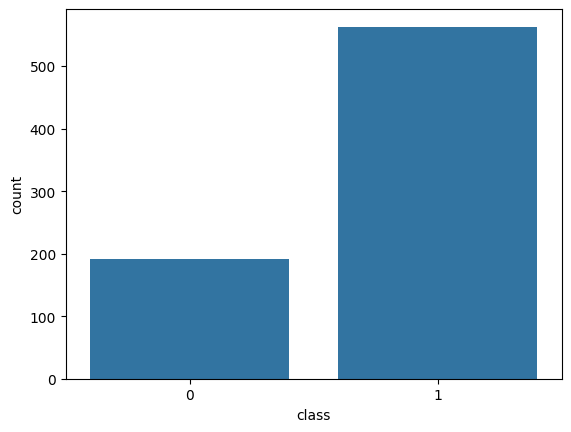

In [89]:
sns.countplot(x='class',data=df)


# Exploring Imabalance In Dataset

In [67]:
df['class'].value_counts()

,count
class,
1,563
0,192


# Split data into X & Y

In [13]:
X = df.drop(['class'], axis=1)
y = df['class']
print('Feature (X) Shape Before Balancing :', X.shape)
print('Target (y) Shape Before Balancing :', y.shape)

Feature (X) Shape Before Balancing : (755, 753)
Target (y) Shape Before Balancing : (755,)


# Scaling features between -1 and 1  for mormalization

In [ ]:
scaler = MinMaxScaler((-1,1))
X_features = scaler.fit_transform(X)

# Resampling Data

In [14]:
sm = SMOTE(random_state=300)
X, y = sm.fit_resample(X_features, y)

In [15]:
print('Feature (X) Shape After Balancing :', X.shape)
print('Target (y) Shape After Balancing :', y.shape)

Feature (X) Shape After Balancing : (1126, 753)
Target (y) Shape After Balancing : (1126,)


# splitting the dataset into traning and testing sets into 80 - 20

In [17]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.20, random_state=42)

# CHHO-GSA

In [50]:

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


class CHHOGSA_FeatureSelection:
    def __init__(self, n_features, pop_size=30, max_iter=100):
        self.dim = n_features
        self.pop_size = pop_size
        self.max_iter = max_iter

        self.k_max_initial = 15
        self.k_min = 3
        self.rng = np.random.RandomState(SEED)

        self.X = self._initialize_chaotic_pop()
        self.V = np.zeros((self.pop_size, self.dim))

        self.alpha_pos = np.zeros(self.dim)
        self.alpha_score = float("inf")
        self.alpha_mask = np.zeros(self.dim, dtype=int)

    # Chaotic Initialization
    def _logistic_map(self, x, gamma=4.0):
        return gamma * x * (1 - x)

    def _initialize_chaotic_pop(self):
        pop = np.zeros((self.pop_size, self.dim))
        x = self.rng.rand()
        for i in range(self.pop_size):
            for j in range(self.dim):
                x = self._logistic_map(x)
                pop[i, j] = x
        return pop


    # Transfer Function
    def _transfer(self, x):
        v = abs(np.tanh(x))
        return 1 if self.rng.rand() < v else 0

    def _get_binary_features(self, position):
        return np.array([self._transfer(v) for v in position])

    # Elitism
    def _apply_elitism(self):
        self.X[0] = self.alpha_pos.copy()

    # Lévy Flight
    def levy(self, dim):
        beta = 1.5
        sigma = (
            math.gamma(1 + beta)
            * math.sin(math.pi * beta / 2)
            / (
                math.gamma((1 + beta) / 2)
                * beta
                * 2 ** ((beta - 1) / 2)
            )
        ) ** (1 / beta)

        u = self.rng.randn(dim) * sigma
        v = self.rng.randn(dim)

        return u / (np.abs(v) ** (1 / beta) + 1e-10)

    # HHO (Exploration)
    def perform_hho(self, iter_idx):
        T = self.max_iter

        for i in range(1, self.pop_size):
            E0 = 2 * self.rng.rand() - 1
            E = 2 * E0 * (1 - (iter_idx / T))

            if np.abs(E) >= 1:
                q = self.rng.rand()
                if q >= 0.5:
                    idx = self.rng.randint(self.pop_size)
                    self.X[i] = self.X[idx] - self.rng.rand() * np.abs(
                        self.X[idx] - 2 * self.rng.rand() * self.X[i]
                    )
                else:
                    self.X[i] = (
                        self.alpha_pos - np.mean(self.X, axis=0)
                    ) - self.rng.rand(self.dim) * np.abs(
                        self.alpha_pos - self.X[i]
                    )
            else:
                r = self.rng.rand()

                if r >= 0.5 and np.abs(E) >= 0.5:
                    J = 2 * (1 - self.rng.rand())
                    self.X[i] = (
                        self.alpha_pos - self.X[i]
                    ) - E * np.abs(J * self.alpha_pos - self.X[i])

                elif r >= 0.5:
                    self.X[i] = self.alpha_pos - E * np.abs(
                        self.alpha_pos - self.X[i]
                    )

                else:
                    LF = self.levy(self.dim)
                    self.X[i] = self.alpha_pos - E * np.abs(
                        LF * self.alpha_pos - self.X[i]
                    )

            self.X[i] = np.clip(self.X[i], 0, 1)

    # GSA (Exploitation)
    def perform_gsa(self, X_train, y_train, iter_idx):
        G0 = 100
        alpha = 20
        eps = 1e-10

        scores = np.zeros(self.pop_size)

        for j in range(self.pop_size):
            mask = self._get_binary_features(self.X[j])
            scores[j] = self.fitness_function(mask, X_train, y_train)

        best = np.min(scores)
        worst = np.max(scores)

        if abs(best - worst) < eps:
            mass = np.ones(self.pop_size) / self.pop_size
        else:
            q = (scores - worst) / (best - worst + eps)
            mass = q / (np.sum(q) + eps)

        k_best = int(self.pop_size * (1 - iter_idx / self.max_iter))
        k_best = max(1, k_best)
        best_indices = np.argsort(scores)[:k_best]

        G = G0 * np.exp(-alpha * (iter_idx / self.max_iter))

        for i in range(1, self.pop_size):
            acc = np.zeros(self.dim)

            for j in best_indices:
                if i != j:
                    R = np.linalg.norm(self.X[i] - self.X[j])
                    acc += self.rng.rand() * G * (mass[j] / (R + eps)) * (
                        self.X[j] - self.X[i]
                    )

            acc = acc / (mass[i] + eps)

            self.V[i] = 0.7 * self.V[i] + acc
            self.X[i] = self.X[i] + self.V[i]
            self.X[i] = np.clip(self.X[i], 0, 1)

   
    # Chaotic Local Search
    def chaotic_search_step(self):
        x = self.rng.rand()
        for i in range(1, self.pop_size):
            for j in range(self.dim):
                x = self._logistic_map(x)
                self.X[i, j] = np.clip(
                    self.alpha_pos[j] + (x - 0.5) * 0.3,
                    0, 1
                )

  
    # Dynamic Weights
    def compute_dynamic_weights(self, acc, fnr, unc, feat_r):
        eps = 1e-8
        m1 = 1 - acc
        m2 = fnr
        m3 = unc
        m4 = feat_r

        total = m1 + m2 + m3 + m4 + eps
        return m1 / total, m2 / total, m3 / total, m4 / total

  
    # Fitness Function 
    def fitness_function(self, mask, X, y):
        selected = np.where(mask == 1)[0]

        if len(selected) == 0:
            return 1e10

        X_sel = X[:, selected]
        model = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=SEED)

        try:
            
            model.fit(X_sel, y)
            
            preds_prob = model.predict_proba(X_sel)
            preds = np.argmax(preds_prob, axis=1)

            acc = accuracy_score(y, preds)
            raw_logloss = log_loss(y, preds_prob)
            unc = raw_logloss / (raw_logloss + 1)

            cm = confusion_matrix(y, preds)

            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
                fnr = fn / (fn + tp + 1e-10)
            else:
                fnr = 0.0

            feat_r = len(selected) / self.dim

            w1, w2, w3, w4 = self.compute_dynamic_weights(
                acc, fnr, unc, feat_r
            )

            return w1 * (1 - acc) + w2 * fnr + w3 * unc + w4 * feat_r

        except:
            return 1e10


    # Main Training Loop
    def fit(self, X_train, y_train):
        best_history = []
        stagnation_counter = 0
        
        # Start with HHO for Exploration
        current_algo = "HHO"

        for j in range(self.pop_size):
            mask = self._get_binary_features(self.X[j])
            score = self.fitness_function(mask, X_train, y_train)

            if score < self.alpha_score:
                self.alpha_score = score
                self.alpha_pos = self.X[j].copy()
                self.alpha_mask = mask.copy()

        self._apply_elitism()

        for i in range(self.max_iter):
            current_k_max = int(
                self.k_max_initial
                - (self.k_max_initial - self.k_min) * (i / self.max_iter)
            )

            if current_algo == "HHO":
                self.perform_hho(i)
            else:
                self.perform_gsa(X_train, y_train, i)

            for j in range(self.pop_size):
                mask = self._get_binary_features(self.X[j])
                score = self.fitness_function(mask, X_train, y_train)

                if score < self.alpha_score:
                    self.alpha_score = score
                    self.alpha_pos = self.X[j].copy()
                    self.alpha_mask = mask.copy()

            self._apply_elitism()
            best_history.append(self.alpha_score)

            if len(best_history) > 1:
                if abs(best_history[-1] - best_history[-2]) < 1e-6:
                    stagnation_counter += 1
                else:
                    stagnation_counter = 0

            # Switch algorithms when stagnation hits
            if stagnation_counter >= current_k_max:
                self.chaotic_search_step()
                stagnation_counter = 0
                current_algo = "GSA" if current_algo == "HHO" else "HHO"

            print(
                f"Iter {i+1:03d} | "
                f"{current_algo} | "
                f"Fitness: {self.alpha_score:.6f} | "
                f"Features: {np.sum(self.alpha_mask)}"
            )

        return self.alpha_mask, self.alpha_score

In [ ]:
selector = CHHOGSA_FeatureSelection(
    n_features=X_train.shape[1],
    pop_size=20,
    max_iter=30
)

best_features, best_score = selector.fit(
    X_train,
    y_train
)

print("\nBest Score:", best_score)

print(
    "Selected Features:",
    np.sum(best_features)
)

selected_idx = np.where(best_features == 1)[0]

print(
    "Feature Indices:",
    selected_idx
)



# Print Selected Features

In [25]:
# Save feature names BEFORE converting to numpy
feature_names = df.drop('status', axis=1).columns

# Selected feature indices
selected_idx = np.where(best_features == 1)[0]

# Selected feature names
selected_feature_names = feature_names[selected_idx]

print("\nSelected Feature Names:")
for feature in selected_feature_names:
    print(feature)

# ML Models

In [49]:
# Feature Selection Output
X_train_sel = X_train[:, selected_idx]
X_test_sel  = X_test[:, selected_idx]

# Specificity Function
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp + 1e-10)



# Models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Neural Network": Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            learning_rate='adaptive',
            max_iter=2000,
            early_stopping=True,
            random_state=42
        ))
    ])
}

# Training + Evaluation
results = []

for name, model in models.items():

    # Train
    model.fit(X_train_sel, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_sel)
    y_test_pred = model.predict(X_test_sel)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Generalization gap
    generalization_gap = train_acc - test_acc

    # ROC-AUC (safe for binary classification)
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    roc = roc_auc_score(y_test, y_prob)

    # F1-score, Precision, and Recall
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')

    # Specificity
    spec = specificity_score(y_test, y_test_pred)

    # Store results
    results.append((
        name,
        train_acc,
        test_acc,
        generalization_gap,
        f1,
        precision,  # Added
        recall,     # Added
        roc,
        spec
    ))

    # Print results
    print("\n======================")
    print(name)
    print(f"Train Accuracy      : {train_acc:.4f}")
    print(f"Test Accuracy       : {test_acc:.4f}")
    print(f"Generalization Gap  : {generalization_gap:.4f}")
    print(f"F1-score            : {f1:.4f}")
    print(f"Precision           : {precision:.4f}")
    print(f"Recall              : {recall:.4f}")
    print(f"ROC-AUC             : {roc:.4f}")
    print(f"Specificity         : {spec:.4f}")



# Summary
print("\n=========== SUMMARY ===========")

for r in results:
    print(
        f"{r[0]:<20} -> "
        f"Train Acc: {r[1]:.4f}, "
        f"Test Acc: {r[2]:.4f}, "
        f"Gap: {r[3]:.4f}, "
        f"F1: {r[4]:.4f}, "
        f"Prec: {r[5]:.4f}, "
        f"Rec: {r[6]:.4f}, "
        f"ROC-AUC: {r[7]:.4f}, "
        f"Spec: {r[8]:.4f}"
    )


Random Forest
Train Accuracy      : 1.0
Test Accuracy       : 0.9513274336283186
Generalization Gap  : 0.04867256637168138
F1-score            : 0.9513608186954989
ROC-AUC             : 0.9906542056074766
Specificity         : 0.9719626168215215

SVM
Train Accuracy      : 0.8533333333333334
Test Accuracy       : 0.8628318584070797
Generalization Gap  : -0.009498525073746267
F1-score            : 0.8627104730582826
ROC-AUC             : 0.940391109714914
Specificity         : 0.8411214953263167

KNN
Train Accuracy      : 0.9277777777777778
Test Accuracy       : 0.8849557522123894
Generalization Gap  : 0.04282202556538839
F1-score            : 0.8841327155340346
ROC-AUC             : 0.9728657818267494
Specificity         : 0.9999999999990654

Logistic Regression
Train Accuracy      : 0.9044444444444445
Test Accuracy       : 0.8716814159292036
Generalization Gap  : 0.03276302851524093
F1-score            : 0.8717493559580283
ROC-AUC             : 0.9579046571899787
Specificity         :